# Task_5_ Sales Prediction Using Python
Sales prediction means predicting how much of a product people will buy based on factors such as the amount spent on advertising across TV, Radio, and Newspaper platforms.
I will use the **Advertising dataset** and build a **Linear Regression** model to predict Sales.

## 1. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')
print('All libraries imported successfully')

All libraries imported successfully


## 2. Load dataset

In [6]:
df = pd.read_csv('Advertising.csv', index_col=0)
print('Dataset shape: ',df.shape)
df.head(10)

Dataset shape:  (200, 4)


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75.0,7.2
7,57.5,32.8,23.5,11.8
8,120.2,19.6,11.6,13.2
9,8.6,2.1,1.0,4.8
10,199.8,2.6,21.2,10.6


## 3. Exploratory Data Analysis (EDA)

In [7]:
# Basic info
print('=== Dataset info: ===')
df.info()

=== Dataset info: ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [8]:
# Statistical summary
print('=== Statistical Summary: ===')
df.describe()

=== Statistical Summary: ===


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [9]:
# Missing values
print('=== Missing Values: ===')
print(df.isnull().sum().sum())

=== Missing Values: ===
0


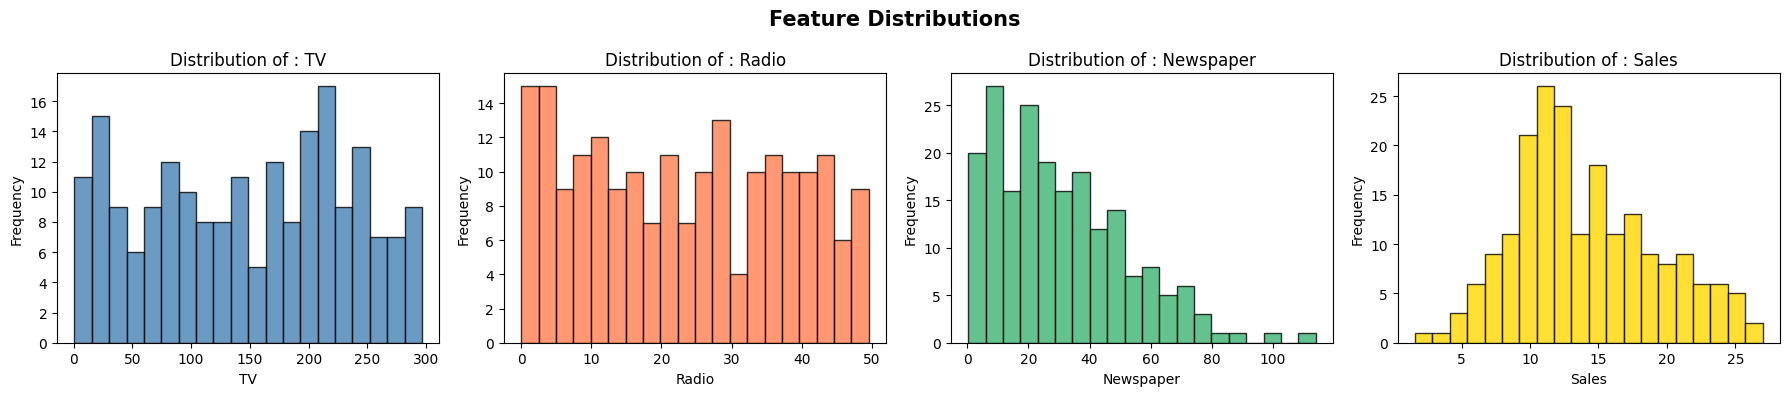

In [12]:
# Distribution of each feature
fig, axes = plt.subplots(1,4,figsize=(18,4))
cols=['TV','Radio','Newspaper','Sales']
colors=['steelblue','coral','mediumseagreen','gold']

for ax, col, colo in zip(axes,cols,colors):
    ax.hist(df[col],color=colo, bins=20, edgecolor='black', alpha=0.8)
    ax.set_title(f'Distribution of : {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

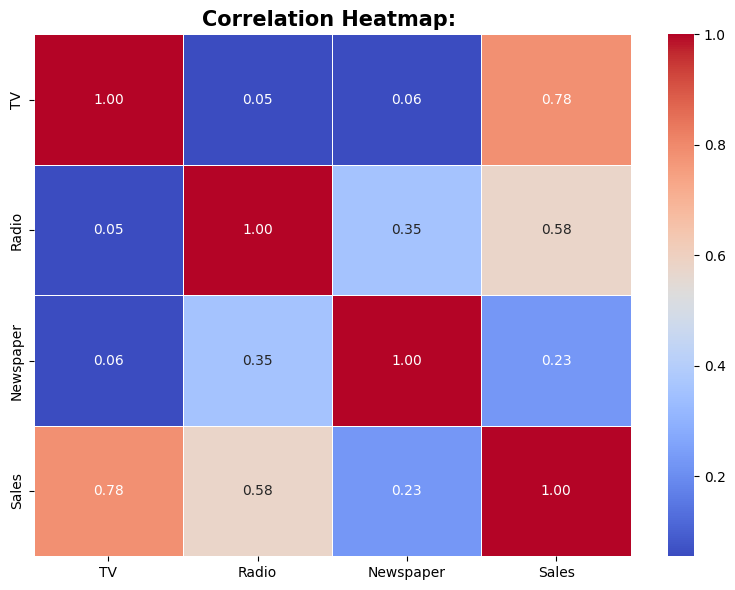

In [13]:
# Correlation Heatmap:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidth=0.5)
plt.title('Correlation Heatmap: ',fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

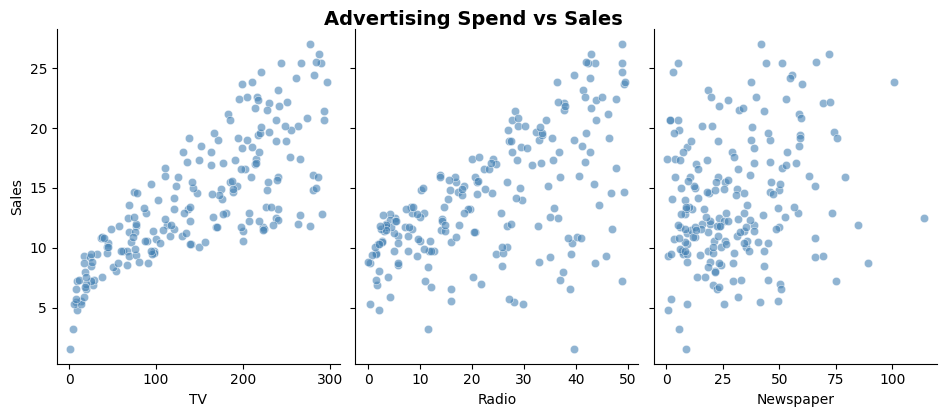

In [14]:
# Pairplot to see relationships
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales',
             height=4, aspect=0.8, kind='scatter', plot_kws={'alpha': 0.6, 'color': 'steelblue'})
plt.suptitle('Advertising Spend vs Sales', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 4. Feature election & Data Splitting

In [15]:
# Define feature (X) and target (Y)
X = df[['TV','Radio','Newspaper']]
y= df['Sales']

print('Features Shape: ',X.shape)
print('Target Shape: ',y.shape)

Features Shape:  (200, 3)
Target Shape:  (200,)


In [19]:
# Split to train, test
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42 
)

print(f'Training Samples: {X_train.shape[0]}')
print(f'Testing Samples: {X_test.shape[0]}')

Training Samples: 160
Testing Samples: 40


## 5. Build & Train Linear Regression Model 